going into more detail on some of the SWE & math basics that we've been relying on:
- callbacks; great technique for SWE & for researchers because they allow you to build things that you can quickly adjust & add things in & pull them out again
- variants
- python concepts:
  - dunder
  - special methods


## Callbacks
### Callbacks as GUI events

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
import ipywidgets as widgets # framework for creating GUI widgets in python

In [3]:
def f(o): print('hi')

From the ipywidget docs:

- the button widget is used to handle mouse clicks.
- The `on_click` method of the Button can be used to register function to be called when the button is clicked

In [5]:
w = widgets.Button(description='Click me')

In [6]:
w

Button(description='Click me', style=ButtonStyle())

hi
hi


In [7]:
w.on_click(f)

- told `w`; when a click occurs - call back to `f` fn & run it
- `f` is a fn that we treat as an object. we're not calling the fn (just passing the fn itself to this method)
- these fns / callbacks that're used in a gui framework are called **events**
  - events are a kind of callback
  - callbacks are a kind of function pointer (although can be much more general as we'll see)

NB: When callbacks are used in this way they are often called "events".

Did you know what you can create interactive apps in Jupyter with these widgets

## Creating your own callback

the event it's going to call back on is after a calculation is complete

In [8]:
from time import sleep

In [9]:
def slow_calculation():
    res = 0
    for i in range(5):
        res += i*i
        sleep(1)
    return res

In [11]:
slow_calculation()

30

want to know how it's going/get some progress.

update the fn to take an argument and add 1 line of code;
- `if cb: cb(i)` - if there's a callback; call it and pass in the epoch number `i`

In [12]:
def slow_calculation(cb=None):
    res = 0
    for i in range(5):
        res += i*i
        sleep(1)
        if cb: cb(i)
    return res

In [13]:
def show_progress(epoch):
    print(f"Awesome! We've finished epoch {epoch}!")

In [14]:
slow_calculation(show_progress)

Awesome! We've finished epoch 0!
Awesome! We've finished epoch 1!
Awesome! We've finished epoch 2!
Awesome! We've finished epoch 3!
Awesome! We've finished epoch 4!


30

## Lambdas and partials

rather than defining a fn just for the purpose of using it once, we can define the fn at the point we use it using `lambda` notation

identical functionality to above
- a convenience for times when you want to define the callback at the same time you use it
- can make you code slightly more concise

In [18]:
slow_calculation(lambda o: print(f"Awesome! We've finished epoch {o}!"))

Awesome! We've finished epoch 0!
Awesome! We've finished epoch 1!
Awesome! We've finished epoch 2!
Awesome! We've finished epoch 3!
Awesome! We've finished epoch 4!


30

In [19]:
def show_progress(exclamation, epoch):
  print(f"{exclamation}! We've finished epoch {epoch}!")

we have to convert this into a fn with only 1 argument
- `lambda o` is a fn with only 1 argument; this fn calls `show_progress` with a particular exclamation
- have converted something with 2 arguments into something with only 1 argument

In [23]:
slow_calculation(lambda o: show_progress("Nice", o))

Nice! We've finished epoch 0!
Nice! We've finished epoch 1!
Nice! We've finished epoch 2!
Nice! We've finished epoch 3!
Nice! We've finished epoch 4!


30

can make it really easy for people to create progress indicators with different exclamations:
- can make a fn `make_show_progress` that returns that `lambda`

In [24]:
def make_show_progress(exclamation):
    _inner = lambda epoch: print(f"{exclamation}! We've finished epoch {epoch}!")
    return _inner

In [25]:
slow_calculation(make_show_progress("Nice!"))

Nice!! We've finished epoch 0!
Nice!! We've finished epoch 1!
Nice!! We've finished epoch 2!
Nice!! We've finished epoch 3!
Nice!! We've finished epoch 4!


30

this is a bit awkward - generally might see it done like this instead:
- see this in fastai all the time
- we define the fn inside it (but this is generally just the same as our lambda), then we return that fn

In [ ]:
def make_show_progress(exclamation):
    # Leading "_" is generally understood to be "private"
    def _inner(epoch): print(f"{exclamation}! We've finished epoch {epoch}!")
    return _inner

instesting. you might think of defining a fn as being a declaritive thing, that as soon as you've defined it is part of the thing that's compiled (how they work in C or C++), but in Python that's not how they work.
- When you define a fn you're basically saying the same as; `_inner = lambda epoch:` which is there's a variable with this name (eg: `_inner`), which is a fn
- that's how we can take `exclamation` passed to `make_show_progress` and use it inside the `_inner`
  - every time you call `make_show_progress` it's going to make a new fn `_inner` internally with a different `exclamation`
  - so it'll work the same as before

In [26]:
slow_calculation(make_show_progress("Nice!"))

Nice!! We've finished epoch 0!
Nice!! We've finished epoch 1!
Nice!! We've finished epoch 2!
Nice!! We've finished epoch 3!
Nice!! We've finished epoch 4!


30

This thing where you create a fn that stores some information from the external context (and it can be different every time) is called a **closure**
- a concept you'll come across a lot (particularly in JavaScript)

In [27]:
f2 = make_show_progress("Terrific")

In [28]:
slow_calculation(f2)

Terrific! We've finished epoch 0!
Terrific! We've finished epoch 1!
Terrific! We've finished epoch 2!
Terrific! We've finished epoch 3!
Terrific! We've finished epoch 4!


30

In [29]:
slow_calculation(make_show_progress("Amazing"))

Amazing! We've finished epoch 0!
Amazing! We've finished epoch 1!
Amazing! We've finished epoch 2!
Amazing! We've finished epoch 3!
Amazing! We've finished epoch 4!


30

In [30]:
from functools import partial

Because it's so often that you want to take a fn that takes 2 parameters and turn it into a fn that takes 1 param python (and most languages) has a way to do that; `partial` function application

In [31]:
slow_calculation(partial(show_progress, "OK I guess"))

OK I guess! We've finished epoch 0!
OK I guess! We've finished epoch 1!
OK I guess! We've finished epoch 2!
OK I guess! We've finished epoch 3!
OK I guess! We've finished epoch 4!


30

In [32]:
f2 = partial(show_progress, "OK I guess")

In [35]:
# f2()

## Callbacks as callable classes

most of what we've seen last week did not use a fn but a class as a callback

so we could do exactly the same thing, but pretty much any place you can use a closure you can also use a class
- instead of storing the state away inside the closure, we can store our state (eg: `exclamation`) inside `self`, passing it into `__init__`

here's exactly the same thing we saw before as a class:

In [36]:
class ProgressShowingCallback():
    def __init__(self, exclamation="Awesome"): self.exclamation = exclamation
    def __call__(self, epoch): print(f"{self.exclamation}! We've finished epoch {epoch}!")

In [37]:
cb = ProgressShowingCallback("Just super")

In [40]:
# cb("Hi")

In [39]:
slow_calculation(cb)

Just super! We've finished epoch 0!
Just super! We've finished epoch 1!
Just super! We've finished epoch 2!
Just super! We've finished epoch 3!
Just super! We've finished epoch 4!


30

## Multiple callback funcs; `*args` and `**kwargs`

In [41]:
def f(*args, **kwargs): print(f"args: {args}; kwargs: {kwargs}")

In [42]:
f(3, 'a', thing1="hello")

args: (3, 'a'); kwargs: {'thing1': 'hello'}


- all positional args passed in end up in an `args` tuple
- all key words args end up as a dict called `kwargs`

that's literally all these things do
- PyTorch uses that, eg: when you create an `nn.Sequential` it takes what you pass in as a `*args` -> you just pass them directly and it turns it into a tuple

why do we use this? A few ways to do so
- one way: if you want to wrap some other class or object you can then take a bunch of inputs as `**kwargs` and pass it off to some other functional object

NB: We've been guilty of over-using kwargs in fastai - it's very convenient for the developer, but is annoying for the end-user unless care is taken to ensure docs show all kwargs too. kwargs can also hide bugs (because it might not tell you about a typo in a param name). In R there's a very similar issue (R uses ... for the same thing), and matplotlib uses kwargs a lot too.

most helpful for throwing things together quick & dirty. there are some downsides to using it

But, some places you really want to use it.  
eg: here we rewrite `slow_calculation` to allow the user to create a callback that occurs before & after the calculation occurs
- `after_calc(i, val=res)` - now takes 2 params
  - `i`: the epoch num, `val=res`: what we've calculated so far

In [43]:
def slow_calculation(cb=None):
    res = 0
    for i in range(5):
        if cb: cb.before_calc(i)
        res += i*i
        sleep(1)
        if cb: cb.after_calc(i, val=res)
    return res

In [44]:
class PrintStepCallback():
    def __init__(self): pass
    def before_calc(self, *args, **kwargs): print(f"About to start")
    def after_calc (self, *args, **kwargs): print(f"Done step")

In [45]:
slow_calculation(PrintStepCallback())

About to start
Done step
About to start
Done step
About to start
Done step
About to start
Done step
About to start
Done step


30

in this case the callback didn't care about the epoch num or the value, so it just has `*args` and `**kwargs` in both places - it doesn't have to worry about exactly what's being passed in because it's not using them
- this is a good use of them: to create a fn that's going to be used somewhere else  and you don't care about 1 (or more) of the params, or you want to make things more flexible
- if we remove this we get an error. However if you put in `*args, **kwargs` it'll always work everywhere

Here we can use them to print out those details:
- in this case `**kwargs` has been put at the end because maybe in the future there will be some other stuff that's passed in and we want to make sure this doesn't break -> makes it more resilient

In [46]:
class PrintStatusCallback():
    def __init__(self): pass
    def before_calc(self, epoch, **kwargs): print(f"About to start: {epoch}")
    def after_calc (self, epoch, val, **kwargs): print(f"After {epoch}: {val}")

In [47]:
slow_calculation(PrintStatusCallback())

About to start: 0
After 0: 0
About to start: 1
After 1: 1
About to start: 2
After 2: 5
About to start: 3
After 3: 14
About to start: 4
After 4: 30


30

## Modifying behavior

In [48]:
def slow_calculation(cb=None):
    res = 0
    for i in range(5):
        if cb and hasattr(cb,'before_calc'): cb.before_calc(i)
        res += i*i
        sleep(1)
        if cb and hasattr(cb,'after_calc'):
            if cb.after_calc(i, res):
                print("stopping early")
                break
    return res

In [49]:
class PrintAfterCallback():
    def after_calc (self, epoch, val):
        print(f"After {epoch}: {val}")
        if val>10: return True

In [50]:
slow_calculation(PrintAfterCallback())

After 0: 0
After 1: 1
After 2: 5
After 3: 14
stopping early


14

what if you want to change the way the calculation is being done?
- here we put our `calc` fn into a class - so now the calculated value is an attribute of the class: `self.res`



In [53]:
class SlowCalculator():
    def __init__(self, cb=None): self.cb,self.res = cb,0

    def callback(self, cb_name, *args):
        if not self.cb: return
        cb = getattr(self.cb,cb_name, None)
        if cb: return cb(self, *args)

    def calc(self):
        for i in range(5):
            self.callback('before_calc', i)
            self.res += i*i
            sleep(1)
            if self.callback('after_calc', i):
                print("stopping early")
                break

now we can do a callback that "reaches" back inside the calculator and changes it:
- `if calc.res<3: calc.res = calc.res*2` is going to double the result if it's < 3

In [54]:
class ModifyingCallback():
    def after_calc (self, calc, epoch):
        print(f"After {epoch}: {calc.res}")
        if calc.res>10: return True
        if calc.res<3: calc.res = calc.res*2

In [55]:
calculator = SlowCalculator(ModifyingCallback())

In [56]:
calculator.calc()
calculator.res

After 0: 0
After 1: 1
After 2: 6
After 3: 15
stopping early


15

this is somewhat the ultimately flexible callback system

in this case we have to pass the calculator (`calc`) object to the callback
- we do so by defining a callback method (`callback`)
  - checks to see if it's defined: `if not self.cb: return`
  - grabs it: `cb = getattr(self.cb,cb_name, None)`
  - calls it" `if cb: return cb(self, *args)` passing in the calcator object itself (`self`)

last week; instead of defining the `callback` method we called it; `__call__` which means we can do it as so:

In [57]:
class SlowCalculator():
    def __init__(self, cb=None): self.cb,self.res = cb,0

    def __call__(self, cb_name, *args):     # updated
        if not self.cb: return
        cb = getattr(self.cb,cb_name, None)
        if cb: return cb(self, *args)

    def calc(self):
        for i in range(5):
            self('before_calc', i)          # updated
            self.res += i*i
            sleep(1)
            if self('after_calc', i):       # updated
                print("stopping early")
                break

## `__dunder__` thingies

Anything that looks like `__this__` is, in some way, special.  
Python, or some library, can define some functions that they will call at certain documented times.  
For instance, when your class is setting up a new object, python will call `__init__`. These are defined as part of the python data model.

For instance, if python sees `+`, then it will call the special method `__add__`.  
If you try to display an object in Jupyter (or lots of other places in Python) it will call `__repr__`.

Jeremy: I like in python that all of the magic names actually look "magic" - they all look like `__this__`

In [58]:
class SloppyAdder():
    def __init__(self,o): self.o=o
    def __add__(self,b): return SloppyAdder(self.o + b.o + 0.01)
    def __repr__(self): return str(self.o)

In [59]:
a = SloppyAdder(1)
b = SloppyAdder(2)
a+b

3.01

Special methods you should probably know about (see data model link above) are:

- `__getitem__`
- `__getattr__`
- `__setattr__`
- `__del__`
- `__init__`
- `__new__`
- `__enter__`
- `__exit__`
- `__len__`
- `__repr__`
- `__str__`

refer to the docs to see what these do (we use all of these in this course)

## Variance and stuff
### Variance
Variance is the average of how far away each data point is from the mean. E.g.:

In [61]:
t = torch.tensor([1.,2.,4.,18]); t

tensor([ 1.,  2.,  4., 18.])

In [62]:
m = t.mean(); m

tensor(6.2500)

In [63]:
(t-m).mean()

tensor(0.)

Oops. We can't do that. Because by definition the positives and negatives cancel out. So we can fix that in one of (at least) two ways:

In [64]:
(t-m).pow(2).mean() # variance

tensor(47.1875)

In [65]:
(t-m).abs().mean() # mean absolute deviation

tensor(5.8750)

But the first of these is now a totally different scale, since we squared. So let's undo that at the end.

In [66]:
(t-m).pow(2).mean().sqrt() # stddev

tensor(6.8693)

They're still different. Why?

Note that we have one outlier (`18`).  
In the version where we square everything, it makes that much bigger than everything else.

`(t-m).pow(2).mean()` is refered to as **variance**. It's a measure of how spread out the data is, and is particularly sensitive to outliers.

When we take the `sqrt` of the **variance**, we get the **standard deviation**. Since it's on the same kind of scale as the original data, it's generally more interpretable. However, since `sqrt(1)==1`, it doesn't much matter which we use when talking about unit variance for initializing neural nets.

`(t-m).abs().mean()` is referred to as the **mean absolute deviation**. It isn't used nearly as much as it deserves to be, because mathematicians don't like how awkward it is to work with. But that shouldn't stop us, because we have computers and stuff.



sidenote: there's a lot of places where replacing things involving squares with things involving absolute values often tend to work better

Here's a useful thing to note about variance:

In [67]:
(t-m).pow(2).mean(), (t*t).mean() - (m*m)

(tensor(47.1875), tensor(47.1875))

### Covariance and correlation

In [68]:
t

tensor([ 1.,  2.,  4., 18.])

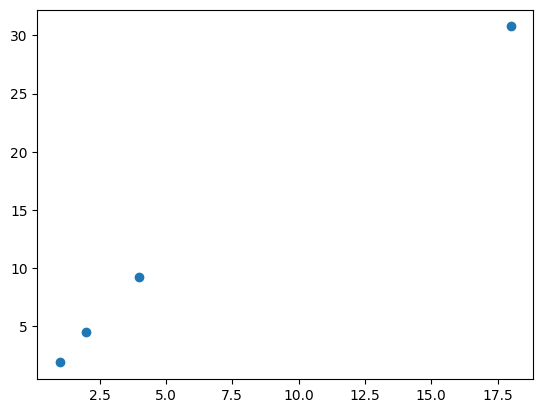

In [69]:
# `u` is twice `t`, plus a bit of randomness
u = t*2
u *= torch.randn_like(t)/10+0.95

plt.scatter(t, u);

In [70]:
prod = (t-t.mean())*(u-u.mean()); prod

tensor([ 50.9158,  30.1686,   5.3671, 225.3899])

In [71]:
prod.mean()

tensor(77.9603)

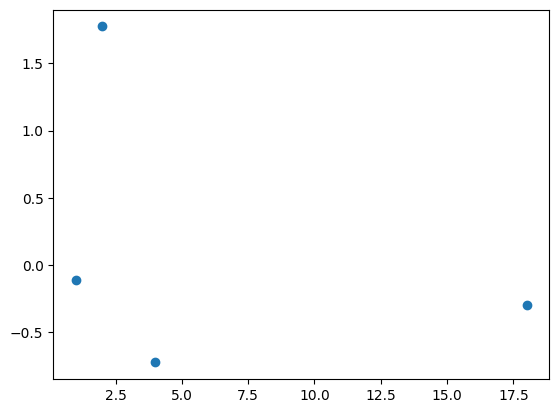

In [72]:
v = torch.randn_like(t)
plt.scatter(t, v);

In [73]:
((t-t.mean())*(v-v.mean())).mean()

tensor(-2.2154)

why is this number much smaller?  
because the initial data lines up - higher on x axis corresponds to higher on y axis -> 2 big positive nums and vice versa with big negatives (in either case end up with big postives after multiplying them together
- this number tells you how much these 2 vary in the same way / how lined up they are

It's generally more conveniently defined like so:

In [74]:
cov = (t*v).mean() - t.mean()*v.mean(); cov

tensor(-2.2154)

Finally, here is the Pearson correlation coefficient:
- covariance / product of std deviations

In [75]:
cov / (t.std() * v.std())

tensor(-0.2524)

It's just a scaled version of the same thing.  

- It can often be useful to see how things vary linearly
- if you want to see how things vary non-linearly you have to create a NN & check the loss and the metrics

Question: Why is it scaled by standard deviation, and not by variance or mean or something else?

### Softmax
Here's our final logsoftmax definition:

In [76]:
def log_softmax(x): return x - x.exp().sum(-1,keepdim=True).log()